
========== MODULE 1 : INGESTION ==========

FIRST 5 ROWS
                         Data  Temperatura  Humidade
0  06/01/2023 19:00:00 -03:00         27.2      82.6
1  06/01/2023 20:00:00 -03:00         27.0      83.0
2  06/01/2023 21:00:00 -03:00         27.0      83.0
3  06/01/2023 22:00:00 -03:00         26.7      83.9
4  06/01/2023 23:00:00 -03:00         26.5      85.4

PARQUET FILE CREATED SUCCESSFULLY

========== MODULE 2 : PREPARATION ==========

MONOTONICITY CHECK
Sequential Order : True

FREQUENCY INSPECTION
Frequency StdDev : 107183.0869010928

MISSING VALUE CHECK
val    0.0
dtype: float64

RESAMPLING DATA
                            val
time                           
2023-01-06 19:00:00-03:00  27.2
2023-01-06 19:15:00-03:00   NaN
2023-01-06 19:30:00-03:00   NaN
2023-01-06 19:45:00-03:00   NaN
2023-01-06 20:00:00-03:00  27.0

INTERPOLATING MISSING VALUES
                             val
time                            
2023-01-06 19:00:00-03:00  27.20
2023-01-06 19:15:00-03:

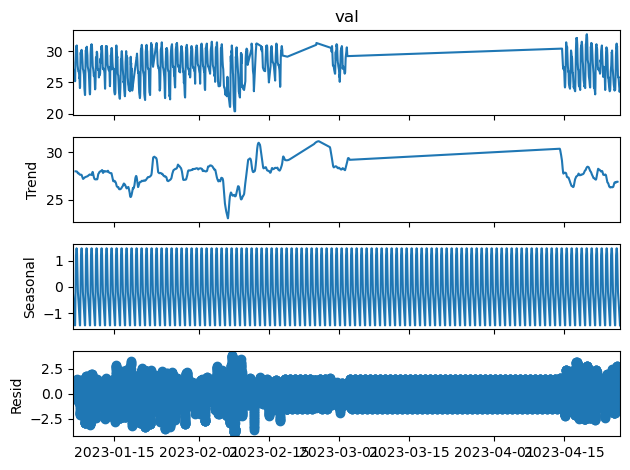

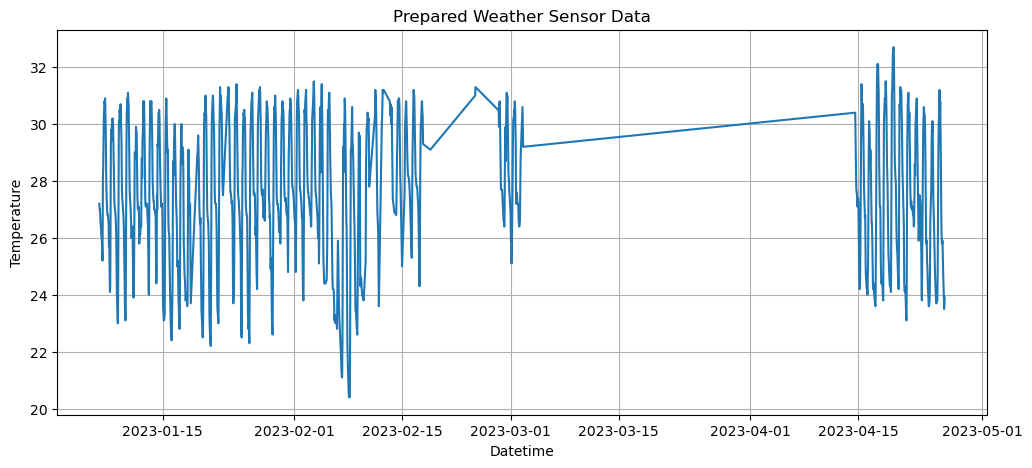


PRACTICAL COMPLETED SUCCESSFULLY


In [6]:
'''
1st : Without funtion based
2nd slide  : with funtion based same programm 
'''

# ==========================================
# PR_25
# Representation and Statistical Exploration
# of Datasets Through Modular Workflow Operations
# ==========================================

# ---------- IMPORT LIBRARIES ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose


# ==========================================
# MODULE 1 : STRUCTURED INGESTION
# ==========================================

print("\n========== MODULE 1 : INGESTION ==========")

# Load dataset
df = pd.read_csv("B2K weather station.csv")

# Display first rows
print("\nFIRST 5 ROWS")
print(df.head())

# Rename columns
df.rename(columns={
    'Data': 'time',
    'Temperatura': 'val'
}, inplace=True)

# Convert datetime column
df['time'] = pd.to_datetime(
    df['time'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Remove invalid datetime rows
df = df.dropna(subset=['time'])

# Set datetime index
df = df.set_index('time')

# Sort data
df = df.sort_index()

# Convert values to numeric
df['val'] = pd.to_numeric(
    df['val'],
    errors='coerce'
)

# Remove invalid values
df = df.dropna(subset=['val'])

# Keep required column
df = df[['val']]

# Save parquet file
df.to_parquet(
    "weather_cache.parquet",
    compression='snappy'
)

print("\nPARQUET FILE CREATED SUCCESSFULLY")


# ==========================================
# MODULE 2 : DATA PREPARATION
# ==========================================

print("\n========== MODULE 2 : PREPARATION ==========")

# Load parquet file
df = pd.read_parquet(
    "weather_cache.parquet"
)

# Monotonicity check
print("\nMONOTONICITY CHECK")

is_monotonic = (
    df.index.is_monotonic_increasing
)

print("Sequential Order :", is_monotonic)

# Frequency inspection
print("\nFREQUENCY INSPECTION")

time_deltas = (
    df.index.to_series()
    .diff()
    .dt.total_seconds()
)

freq_std = time_deltas.std()

print("Frequency StdDev :", freq_std)

# Missing value check
print("\nMISSING VALUE CHECK")

missing_ratio = (
    df.isnull().mean() * 100
)

print(missing_ratio)

# Resampling
print("\nRESAMPLING DATA")

df_resampled = (
    df
    .resample('15min')
    .mean()
)

print(df_resampled.head())

# Interpolation
print("\nINTERPOLATING MISSING VALUES")

df_resampled['val'] = (
    df_resampled['val']
    .interpolate(method='time')
)

print(df_resampled.head())


# ==========================================
# MODULE 3 : STATISTICAL EXPLORATION
# ==========================================

print("\n========== MODULE 3 : EXPLORATION ==========")

# Statistical summary
print("\nSTATISTICAL SUMMARY")

stats = df_resampled['val'].describe()

print(stats)

# Seasonal decomposition
print("\nPERFORMING SIGNAL DECOMPOSITION")

decomposition = seasonal_decompose(
    df_resampled['val'],
    model='additive',
    period=96
)

# Decomposition graphs
decomposition.plot()

plt.show()

# Final visualization
plt.figure(figsize=(12,5))

plt.plot(df_resampled['val'])

plt.title("Prepared Weather Sensor Data")

plt.xlabel("Datetime")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PRACTICAL COMPLETED SUCCESSFULLY")
print("===================================")


PR_25 PRACTICAL STARTED

========== MODULE 1 : INGESTION ==========

FIRST 5 ROWS
                         Data  Temperatura  Humidade
0  06/01/2023 19:00:00 -03:00         27.2      82.6
1  06/01/2023 20:00:00 -03:00         27.0      83.0
2  06/01/2023 21:00:00 -03:00         27.0      83.0
3  06/01/2023 22:00:00 -03:00         26.7      83.9
4  06/01/2023 23:00:00 -03:00         26.5      85.4

PARQUET FILE CREATED SUCCESSFULLY

========== MODULE 2 : PREPARATION ==========

MONOTONICITY CHECK
Sequential Order : True

FREQUENCY INSPECTION
Frequency StdDev : 107183.0869010928

MISSING VALUE CHECK
val    0.0
dtype: float64

RESAMPLING DATA
                            val
time                           
2023-01-06 19:00:00-03:00  27.2
2023-01-06 19:15:00-03:00   NaN
2023-01-06 19:30:00-03:00   NaN
2023-01-06 19:45:00-03:00   NaN
2023-01-06 20:00:00-03:00  27.0

INTERPOLATING MISSING VALUES
                             val
time                            
2023-01-06 19:00:00-03:00  27.2

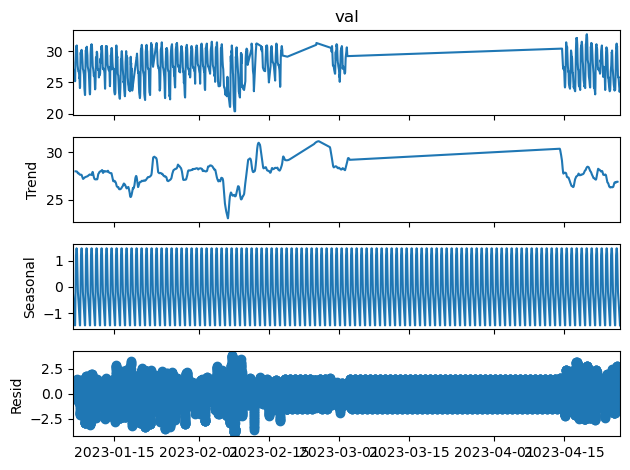

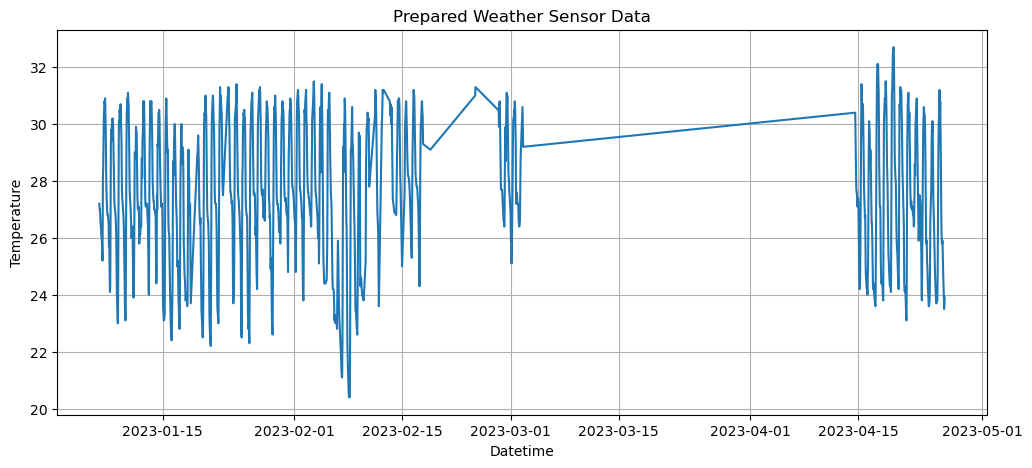


PRACTICAL COMPLETED SUCCESSFULLY


In [5]:
# ==========================================
# PR_25
# Representation and Statistical Exploration
# of Datasets Through Modular Workflow Operations
# Weather Station Dataset
# ==========================================

# ---------- IMPORT LIBRARIES ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose


# ==========================================
# MODULE 1 : STRUCTURED INGESTION
# ==========================================

def ingestion_module():

    """
    Structured ingestion converts raw data
    into analytical format with datetime indexing.
    """

    print("\n========== MODULE 1 : INGESTION ==========")

    # Load dataset
    df = pd.read_csv("B2K weather station.csv")

    print("\nFIRST 5 ROWS")
    print(df.head())

    # Rename required columns
    df.rename(columns={
        'Data': 'time',
        'Temperatura': 'val'
    }, inplace=True)

    # Convert datetime column
    df['time'] = pd.to_datetime(
        df['time'],
        format='mixed',
        dayfirst=True,
        errors='coerce'
    )

    # Remove invalid datetime rows
    df = df.dropna(subset=['time'])

    # Set datetime index
    df = df.set_index('time')

    # Sort sequentially
    df = df.sort_index()

    # Convert sensor values to numeric
    df['val'] = pd.to_numeric(
        df['val'],
        errors='coerce'
    )

    # Remove invalid sensor values
    df = df.dropna(subset=['val'])

    # Keep only required column
    df = df[['val']]

    # Save as parquet
    df.to_parquet(
        "weather_cache.parquet",
        compression='snappy'
    )

    print("\nPARQUET FILE CREATED SUCCESSFULLY")

    return df


# ==========================================
# MODULE 2 : DATA PREPARATION
# ==========================================

def preparation_module():

    """
    Preparation ensures temporal integrity
    using sorting, resampling,
    and interpolation.
    """

    print("\n========== MODULE 2 : PREPARATION ==========")

    # Load parquet file
    df = pd.read_parquet(
        "weather_cache.parquet"
    )

    # ---------- MONOTONICITY CHECK ----------

    print("\nMONOTONICITY CHECK")

    is_monotonic = (
        df.index.is_monotonic_increasing
    )

    print("Sequential Order :", is_monotonic)

    # Fix order if required
    if not is_monotonic:
        df = df.sort_index()

    # ---------- FREQUENCY INSPECTION ----------

    print("\nFREQUENCY INSPECTION")

    time_deltas = (
        df.index.to_series()
        .diff()
        .dt.total_seconds()
    )

    freq_std = time_deltas.std()

    print("Frequency StdDev :", freq_std)

    # ---------- MISSING VALUE CHECK ----------

    print("\nMISSING VALUE CHECK")

    missing_ratio = (
        df.isnull().mean() * 100
    )

    print(missing_ratio)

    # ---------- RESAMPLING ----------

    print("\nRESAMPLING DATA")

    # Convert irregular intervals
    # into fixed 15-minute intervals
    df_resampled = (
        df
        .resample('15min')
        .mean()
    )

    print(df_resampled.head())

    # ---------- INTERPOLATION ----------

    print("\nINTERPOLATING MISSING VALUES")

    df_resampled['val'] = (
        df_resampled['val']
        .interpolate(method='time')
    )

    print(df_resampled.head())

    return df_resampled


# ==========================================
# MODULE 3 : STATISTICAL EXPLORATION
# ==========================================

def exploration_module(df):

    """
    Exploration decomposes time-series data
    into trend, seasonality,
    and residual components.
    """

    print("\n========== MODULE 3 : EXPLORATION ==========")

    # ---------- STATISTICAL SUMMARY ----------

    print("\nSTATISTICAL SUMMARY")

    stats = df['val'].describe()

    print(stats)

    # ---------- SIGNAL DECOMPOSITION ----------

    print("\nPERFORMING SIGNAL DECOMPOSITION")

    decomposition = seasonal_decompose(
        df['val'],
        model='additive',
        period=96
    )

    # ---------- DECOMPOSITION PLOTS ----------

    decomposition.plot()

    plt.show()

    # ---------- DATA VISUALIZATION ----------

    plt.figure(figsize=(12,5))

    plt.plot(df['val'])

    plt.title("Prepared Weather Sensor Data")

    plt.xlabel("Datetime")

    plt.ylabel("Temperature")

    plt.grid(True)

    plt.show()

    return stats


# ==========================================
# MAIN EXECUTION
# ==========================================

print("\n===================================")
print("PR_25 PRACTICAL STARTED")
print("===================================")

# MODULE 1
ingestion_module()

# MODULE 2
prepared_df = preparation_module()

# MODULE 3
statistics = exploration_module(
    prepared_df
)

